In [ ]:
nabled' if HAS_GEOPANDAS else 'Alternative mode'}")

⚠️ GeoPandas not available - Using alternative visualization approach

📊 Environment ready for geographic analysis


# Loading Data

In [ ]:
# File paths

atibility

print(f"\n✅ Column mapping completed for analysis compatibility")

📊 Loading high-paying jobs data...
✅ Data loaded: 10,273 records
🗺️  Using alternative geographic approach...

📈 Dataset Overview:
   • Income range: $100,000 - $1,098,315
   • Average income: $168,094
   • States covered: 50
   • Education levels: 4 (Bachelor's degree, Master's degree, Professional degree...)
   • Gender distribution: {'Male': 6142, 'Female': 4131}
   • Top 5 occupations: {'Software Developers': 1335, 'Registered Nurses': 1080, 'Medical And Health Services Managers': 651, 'Financial Managers': 584, 'Computer And Information Systems Managers': 494}

✅ Column mapping completed for analysis compatibility


## Define Visualization Functions
This section contains a reusable function to plot state-level maps of the United States based on specified data. The function includes options for custom color maps, labels, and scaling.


In [ ]:
() if 'State Abbreviation' in df.columns else df[column_to_plot].describe()
            print(summary.head())

In [ ]:
e_counts'):
            print("📊 Education Level Summary:")
            print(df.value_counts().head(10))

In [ ]:
 print("📊 Creating basic gender summary...")
        if 'Gender' in df.columns:
            print(df['Gender'].value_counts(normalize=True) * 100)

### Data Preparation and Plotting: High-Paying Jobs by State


#### Question1 : Which states have the highest number of high-paying jobs ($100K+ annual income)?

In [ ]:
# Calculate the average annual income by state
print("💰 Analyzing income distribution by state...")
A_income_state = (high_pay_data.groupby(['State Abbreviation'])['Annual Income']
                  .mean()
                  .reset_index()
                  .round(2))

print(f"✅ Income analysis completed for {len(A_income_state)} states")
print(f"📊 Top 5 highest income states:")
top_5 = A_income_state.sort_values('Annual Income', ascending=False).head()
for idx, row in top_5.iterrows():
    print(f"   {row['State Abbreviation']}: ${row['Annual Income']:,.0f}")

# Prepare data for visualization (works witG oP without geopandas)
if HAS_GEOPANDAS and us_states is not None:
    # Merge with geographic data if available
    geo_income_data = A_income_state.merge(us_states, left_on='State Abbreviation', right_on='STUSPS')
    geo_income_data = gpd.GeoDataFrame(geo_income_data, geometry=geo_income_data.geometry)
    # Exclude Alaska (AK) and Hawaii (HI) from the data for easier mapping
    geo_income_data = geo_income_data.loc[~geo_income_data['STUSPS'].isin(['AK', 'HI'])]
    print("🗺️  Geographic data merged successfully")
else:
    # Use the income data directly for alternative visualization
    geo_income_data = A_income_state.copy()
    print("📊 Using direct state income data for visualization")

print(f"\n📈 Data ready for visualization: {len(geo_income_data)} states/territories")

💰 Analyzing income distribution by state...
✅ Income analysis completed for 50 states
📊 Top 5 highest income states:
   ND: $193,110
   DE: $186,226
   IA: $184,801
   KY: $183,565
   AR: $181,644
📊 Using direct state income data for visualization

📈 Data ready for visualization: 50 states/territories


#### Visualization 

🎨 Creating professional income distribution analysis...


🎨 Creating professional income distribution analysis...


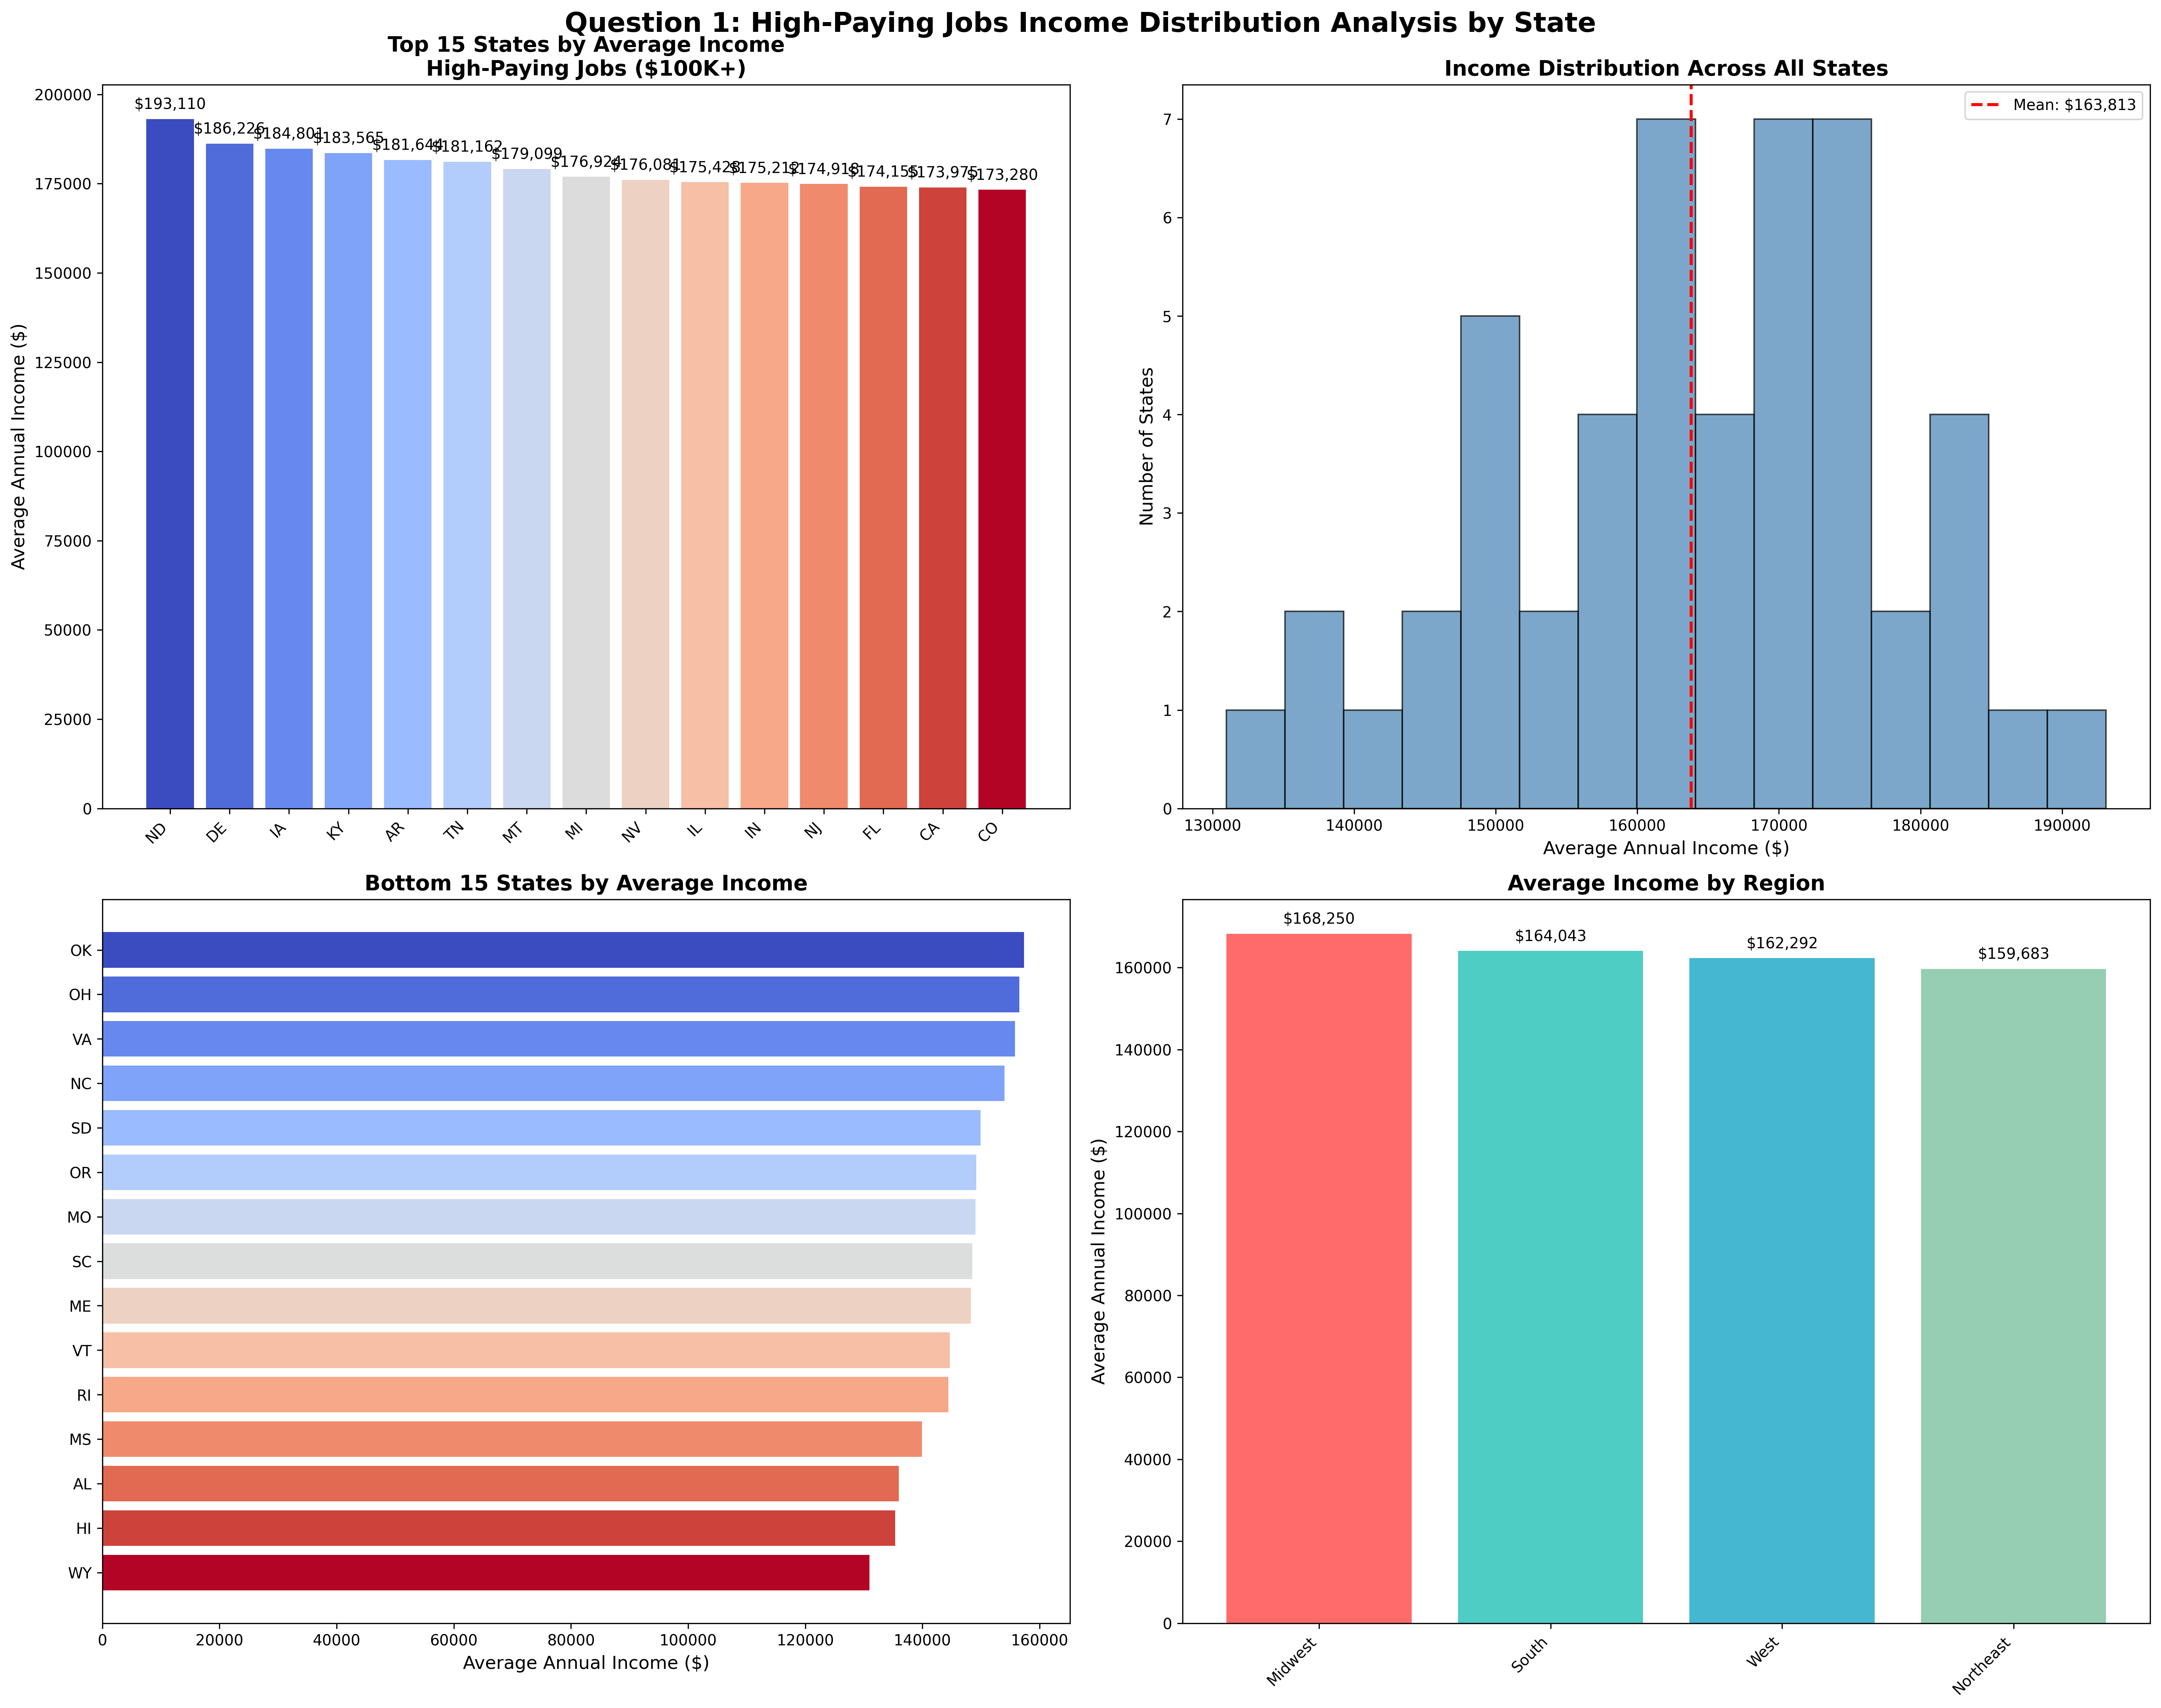

✅ Question 1 analysis completed successfully!
📊 Analysis covers 50 states
💰 Income range: $130,986 - $193,110
📈 National average: $163,813


In [ ]:
rint(f"📈 National average: ${geo_income_data['Annual Income'].mean():,.0f}")

### Question 2: ## Which states have the highest number and the highest concentration of high-paying jobs ($100K+ annual income)?


Step 1: Aggregate High-Paying Job Data by State

In [9]:
# Aggregate high-paying jobs and total jobs by state
job_data = (
    high_pay_data.groupby('State Abbreviation')
    .agg(
        High_Paying_Jobs=('Annual Income', 'size'),
        Total_Jobs=('Employment', 'size'),
        Location_Quotient=('Location Quotient', 'mean')  # Average LQ for better representation
    )
    .reset_index()
)

# Merge with GeoDataFrame for mapping
job_data_geo = pd.merge(us_states, job_data, left_on='STUSPS', right_on='State Abbreviation', how='left')

# Convert to GeoDataFrame
job_data_geo = gpd.GeoDataFrame(job_data_geo, geometry=job_data_geo.geometry)

# Exclude Alaska (AK) and Hawaii (HI) for mapping clarity
job_data_geo = job_data_geo.loc[~job_data_geo['STUSPS'].isin(['AK', 'HI'])]


KeyError: "Column 'Employment' does not exist!"

#### Visualization : 
**Step1 :** Plot High-Paying Jobs Distribution

Map successfully saved to Images\High-Paying_Jobs_Distribution.png


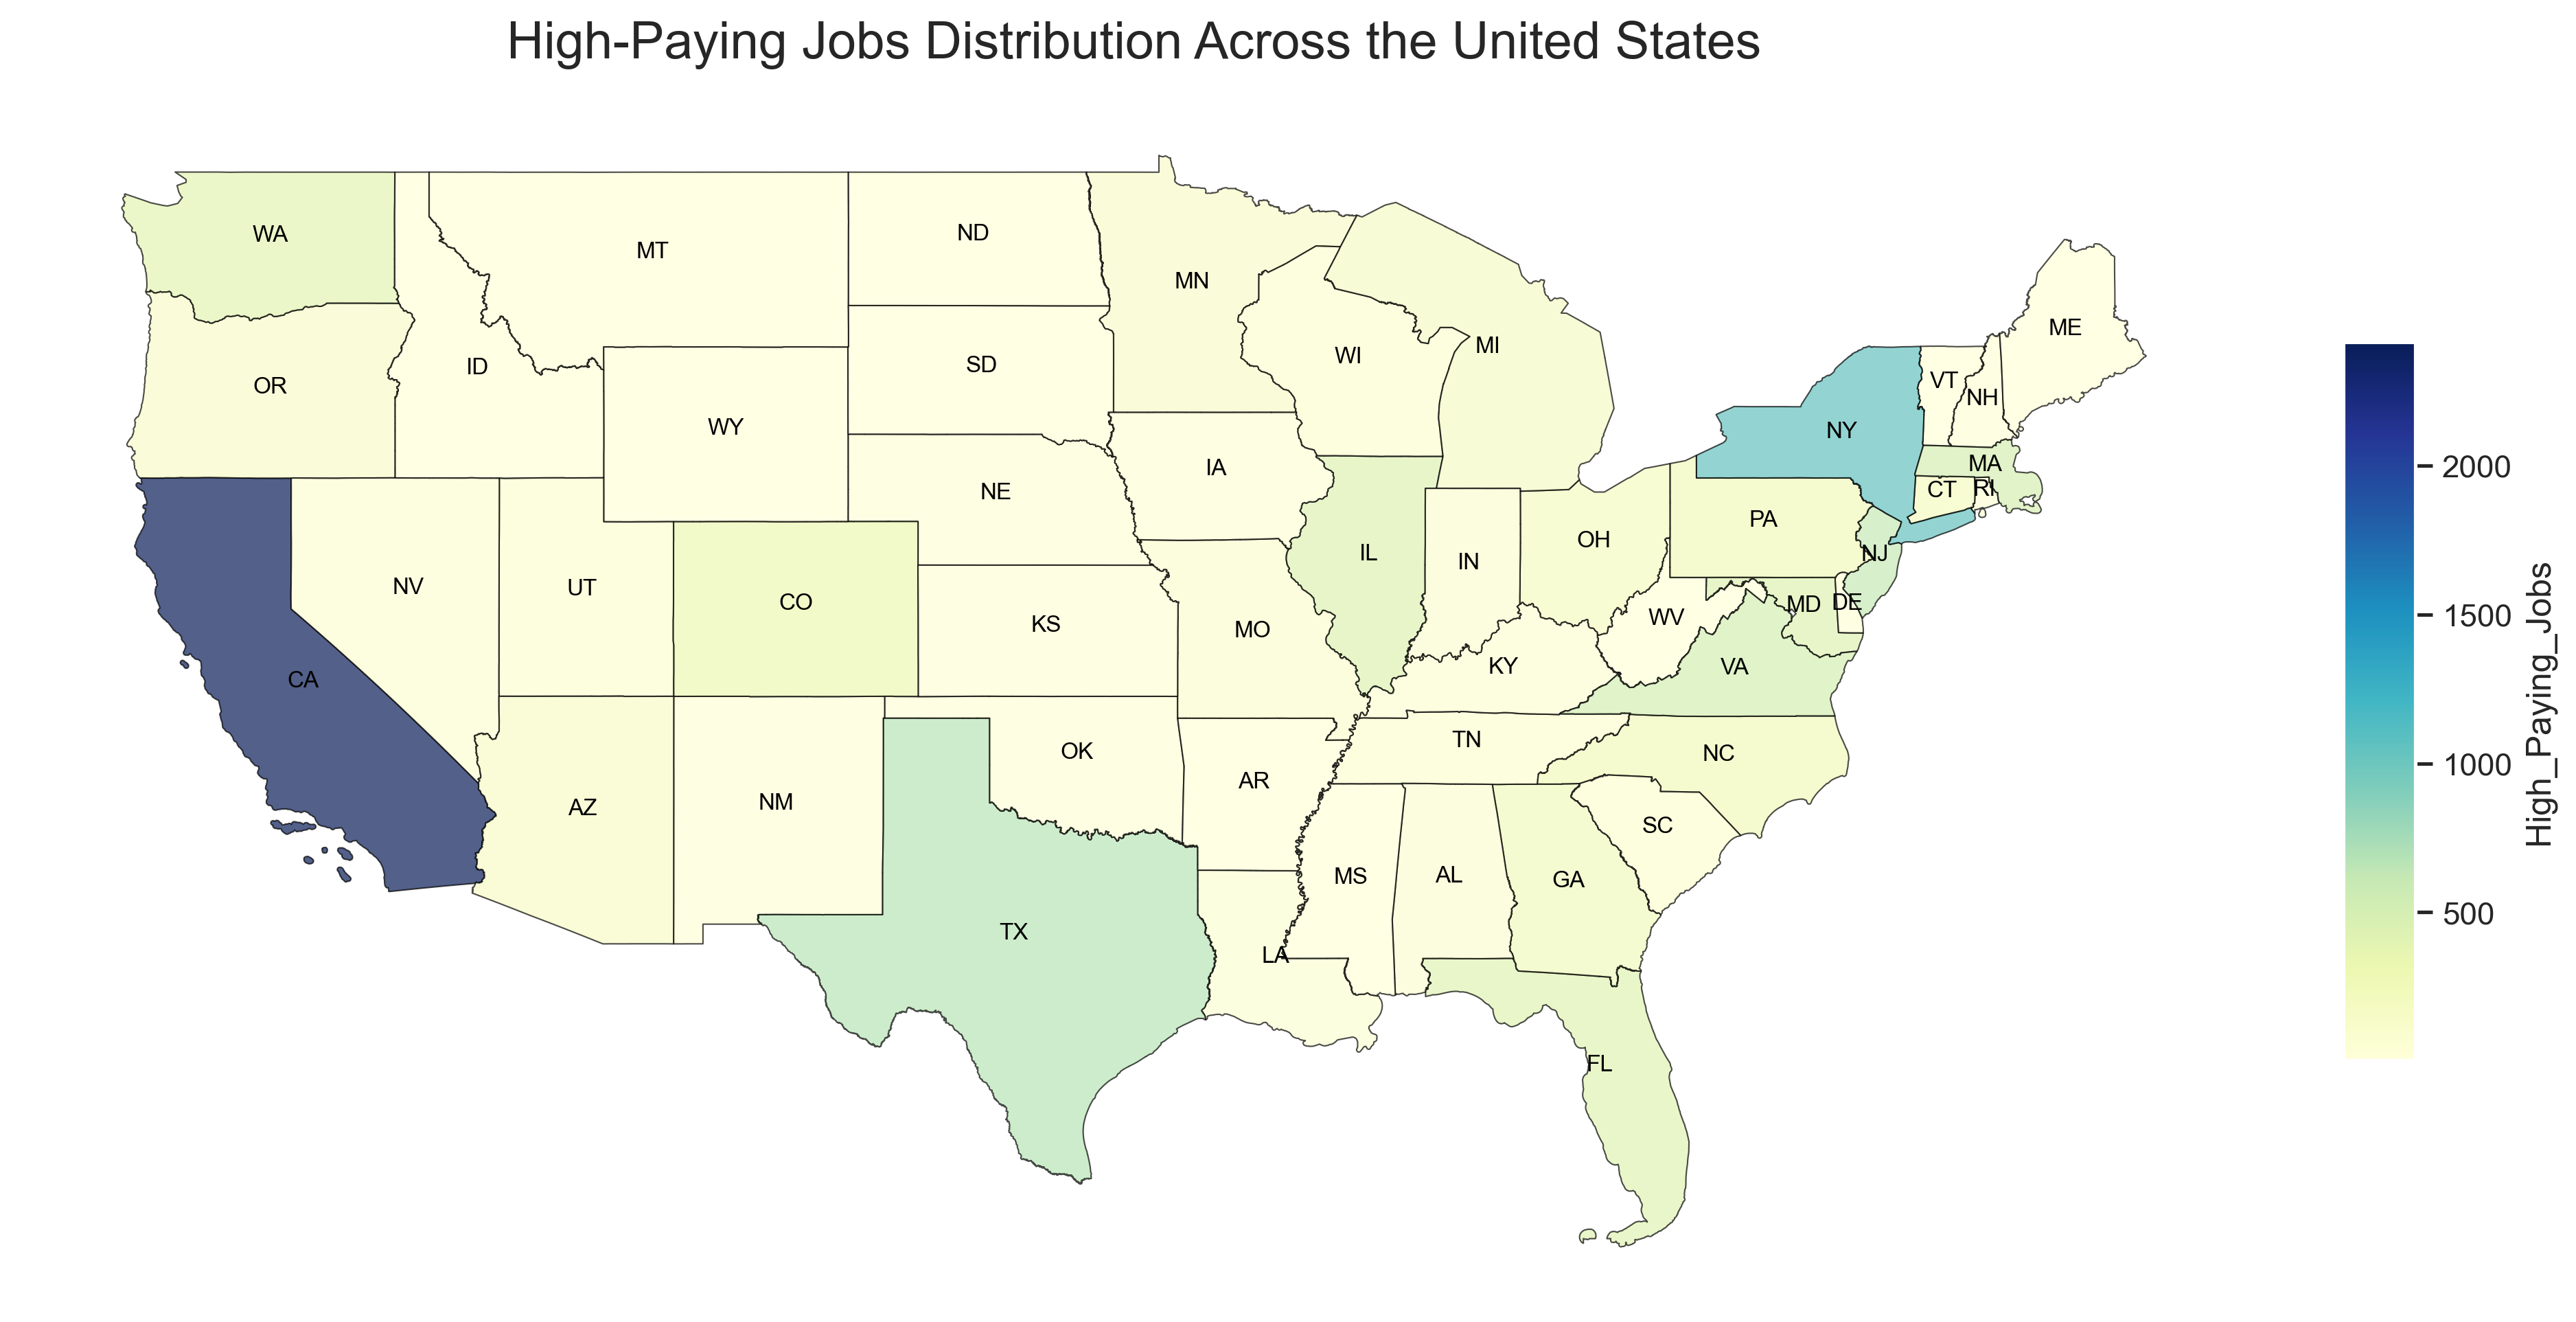

In [ ]:
StatesPlot(
    df=job_data_geo,
    column_to_plot='High_Paying_Jobs',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='High-Paying Jobs Distribution Across the United States',
    filename='High-Paying_Jobs_Distribution.png',
    edge_color='black'
)


**Step 2:** Plot Location Quotient (LQ) Distribution

Map successfully saved to Images\High_Paying_Jobs_LQ_Distribution.png


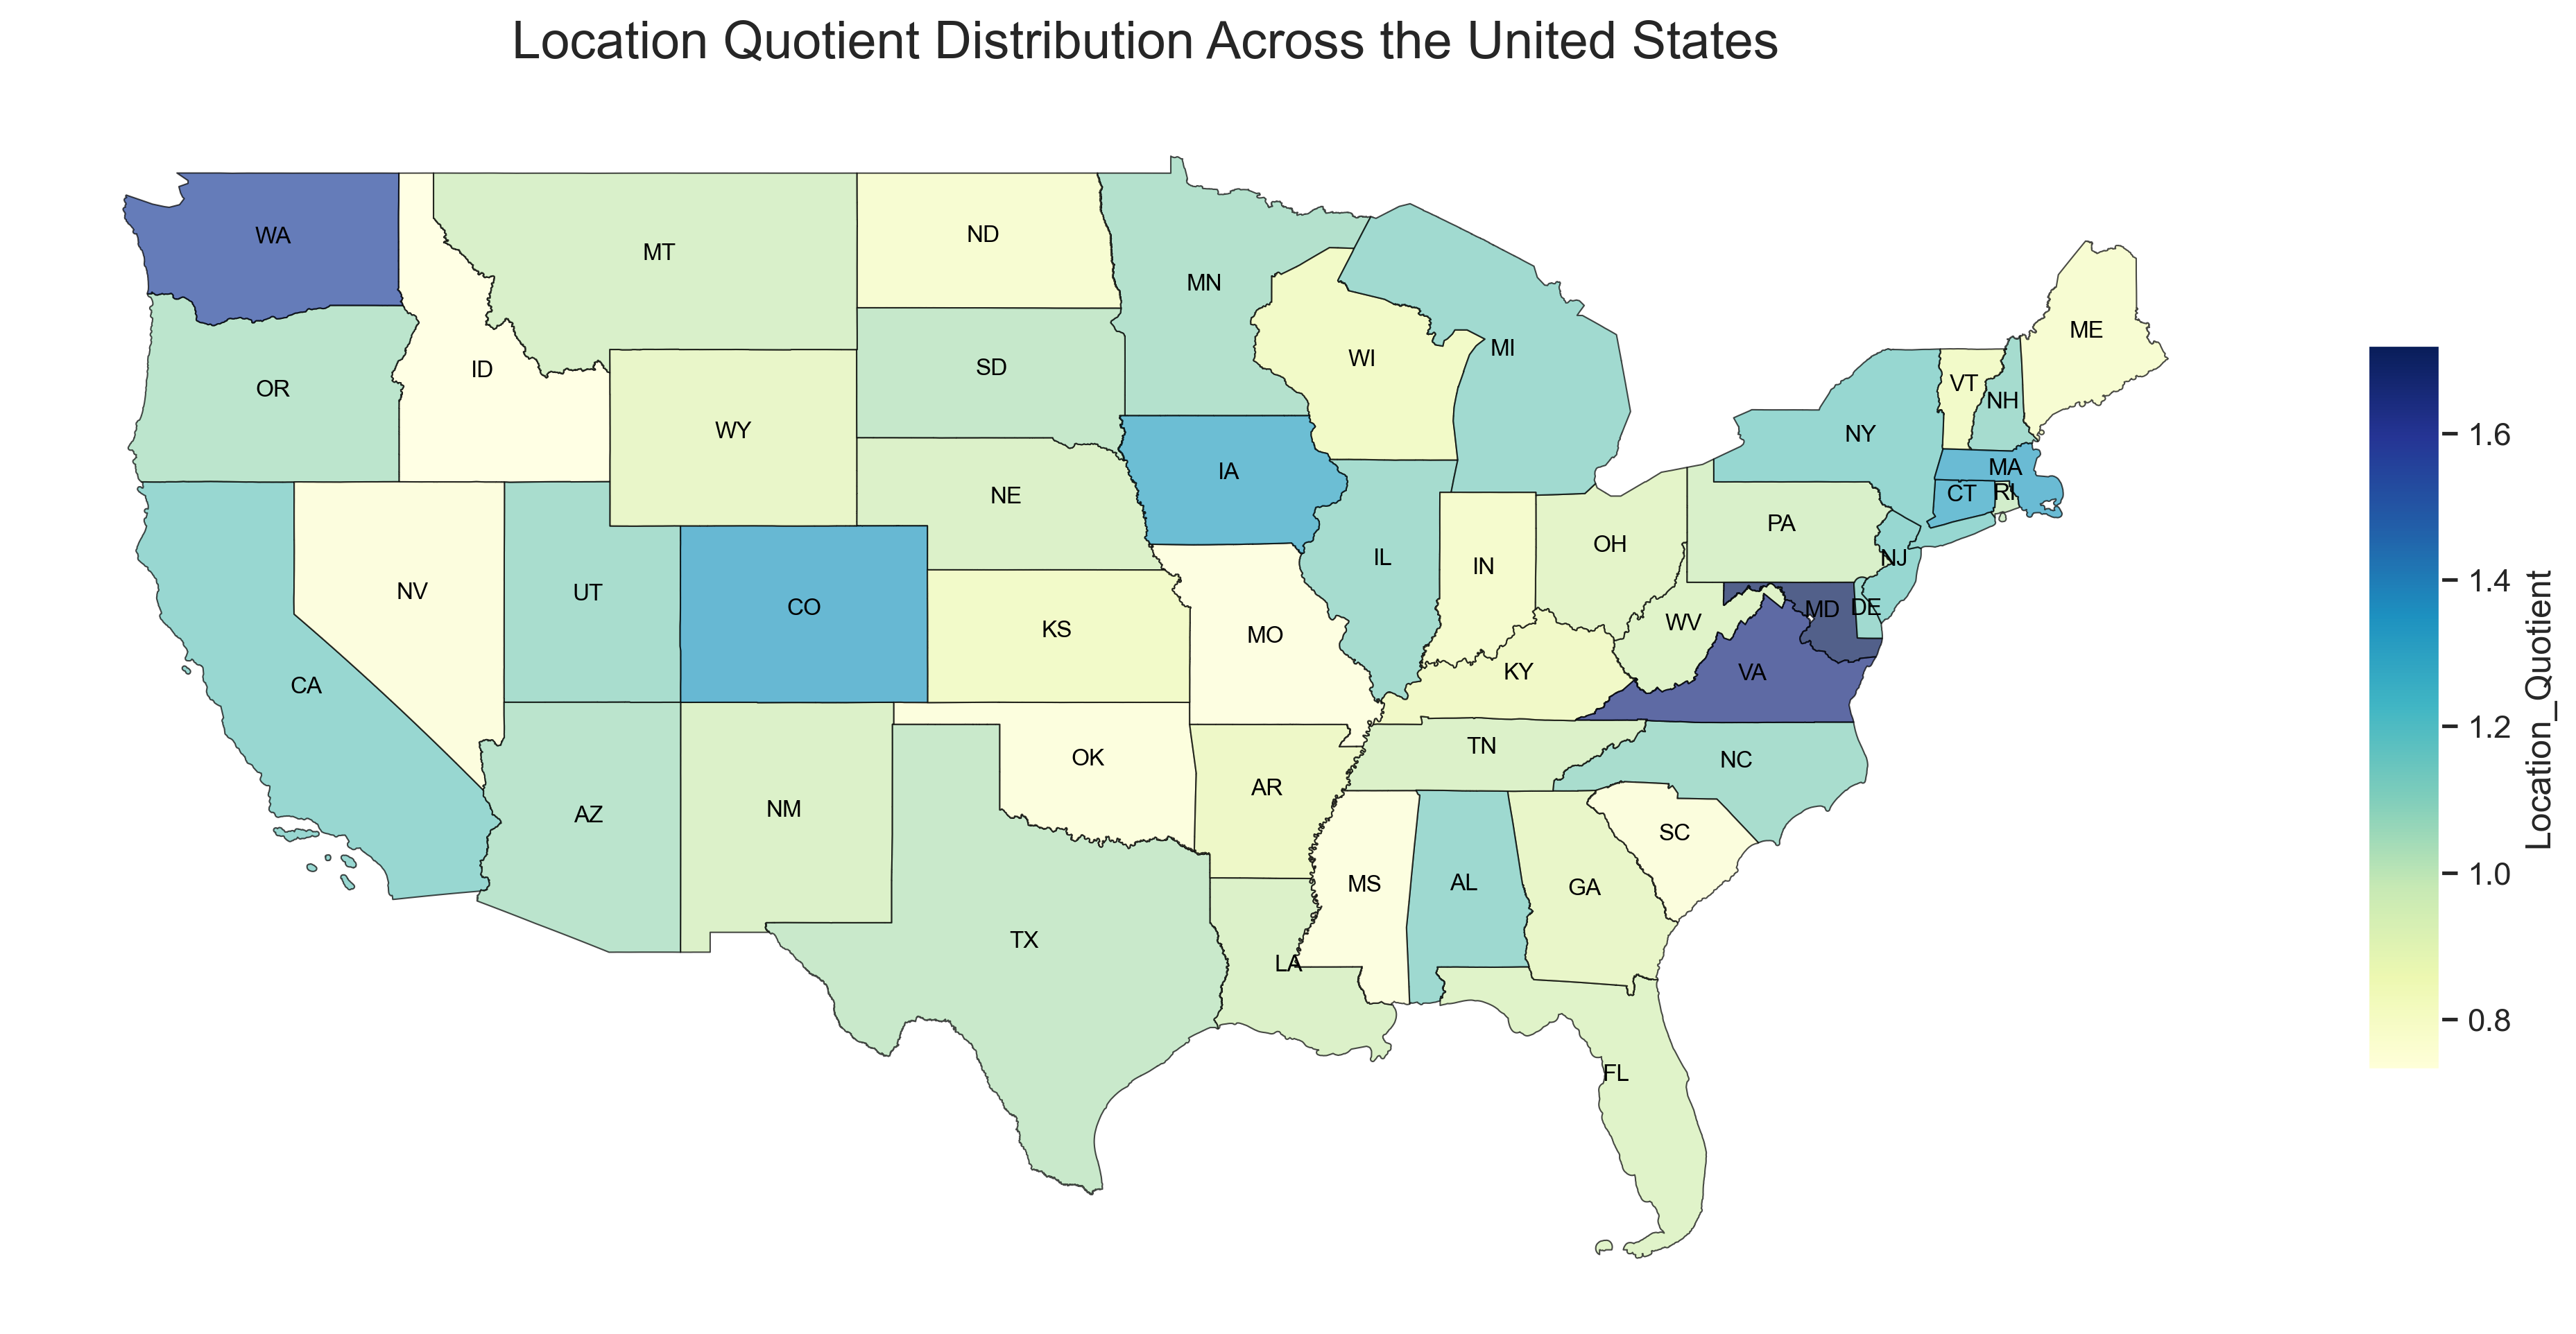

In [ ]:
StatesPlot(
    df=job_data_geo,
    column_to_plot='Location_Quotient',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='Location Quotient Distribution Across the United States',
    filename='High_Paying_Jobs_LQ_Distribution.png',
    edge_color='black'
)

### Question 3: What is the dominant education level for high-paying jobs (earning $100K+) across different states, and how does this reflect regional job market demands?

In [ ]:
# Data Preparation
dominant_education = (
    high_pay_data.groupby(['State Abbreviation', 'Education Level'])
    .size()
    .reset_index(name='Count')
)
# Sort by state and count, descending, and pick the dominant education
dominant_education = dominant_education.sort_values(
    ['State Abbreviation', 'Count'], ascending=[True, False]
).drop_duplicates(subset='State Abbreviation', keep='first')

# Merge with us_states GeoDataFrame for visualization
geo_dominant_education = pd.merge(
    us_states, dominant_education, left_on='STUSPS', right_on='State Abbreviation', how='left'
)

In [ ]:
# Ensure `geo_dominant_education` is a GeoDataFrame for spatial plotting
geo_dominant_education = gpd.GeoDataFrame(geo_dominant_education, geometry='geometry')
# exclude ALska and huwaii
geo_dominant_education=geo_dominant_education.loc[~geo_dominant_education['STUSPS'].isin(['AK', 'HI'])]

#### Visualization 

Map successfully saved to Images\Dominant_education_by_state.png


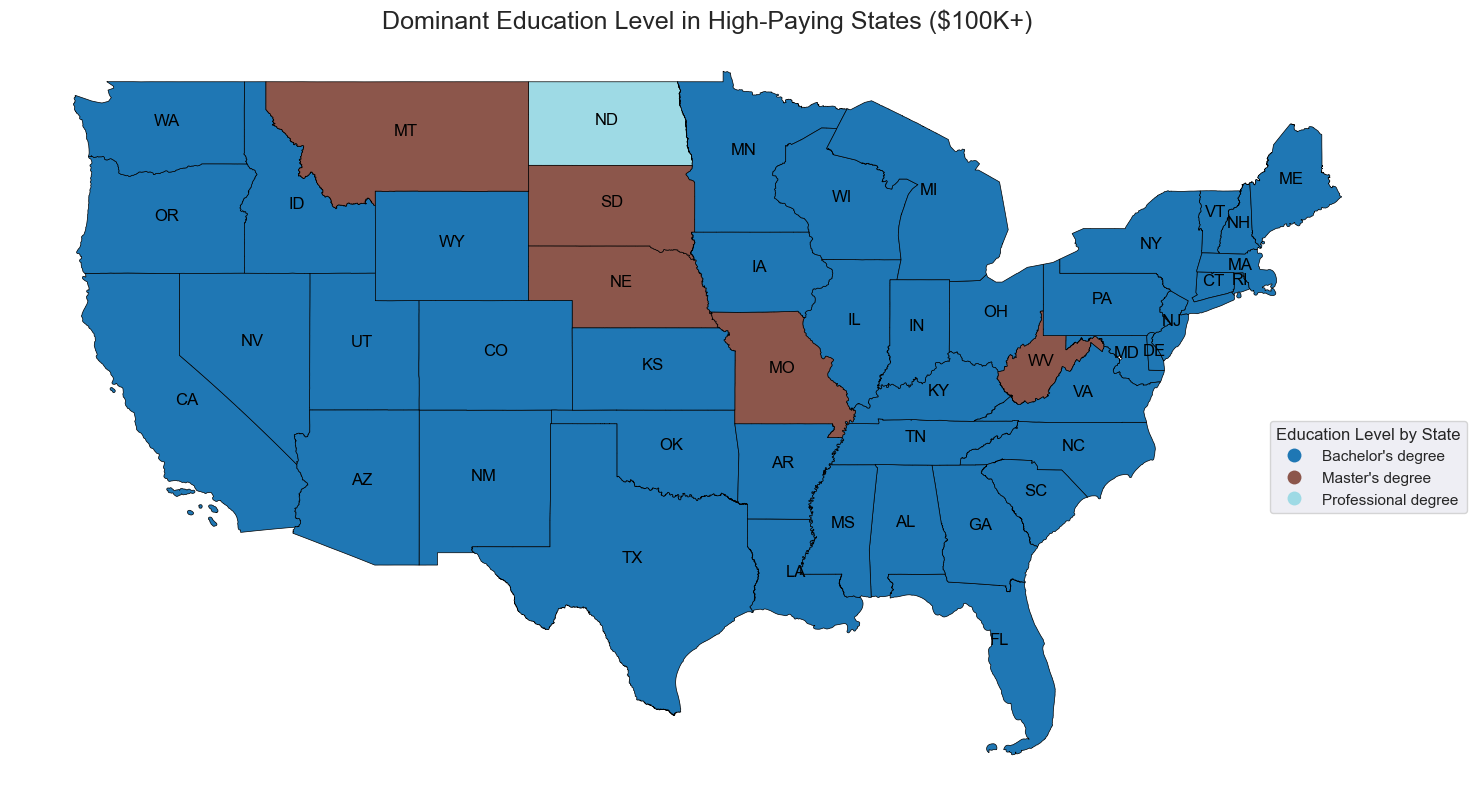

In [ ]:
#Ploting  Results
# Function call with your data and specifications
Education_State(geo_dominant_education, 'Education Level', 
                'Dominant Education Level in High-Paying States ($100K+)', 
                'Dominant_education_by_state.png')


### Question 4: What is the gender distribution in high-paying jobs ($100K+) across different states?


#### Data Preparation

In [ ]:
# Step 1: Filter and Aggregate the Data
# Group by State and Gender to get counts
gender_counts = high_pay_data.groupby(['State Abbreviation', 'Gender']).size().unstack(fill_value=0)

# Step 2: Calculate Percentages
gender_counts['Total'] = gender_counts.sum(axis=1)
gender_counts['Male_Percentage'] = (gender_counts['Male'] / gender_counts['Total']) * 100
gender_counts['Female_Percentage'] = (gender_counts['Female'] / gender_counts['Total']) * 100

# Reset index to have State as a column
gender_counts.reset_index(inplace=True)

# Step 3: Merge with Geographical Data
geo_gender_df = us_states.merge(gender_counts, left_on='STUSPS', right_on='State Abbreviation', how='left')


In [ ]:
#exclude ak and hi
geo_gender_df = geo_gender_df.loc[~geo_gender_df['STUSPS'].isin(['AK', 'HI'])]
# drop bad rows
geo_gender_df=geo_gender_df.dropna(how='any')

#### Visualization 

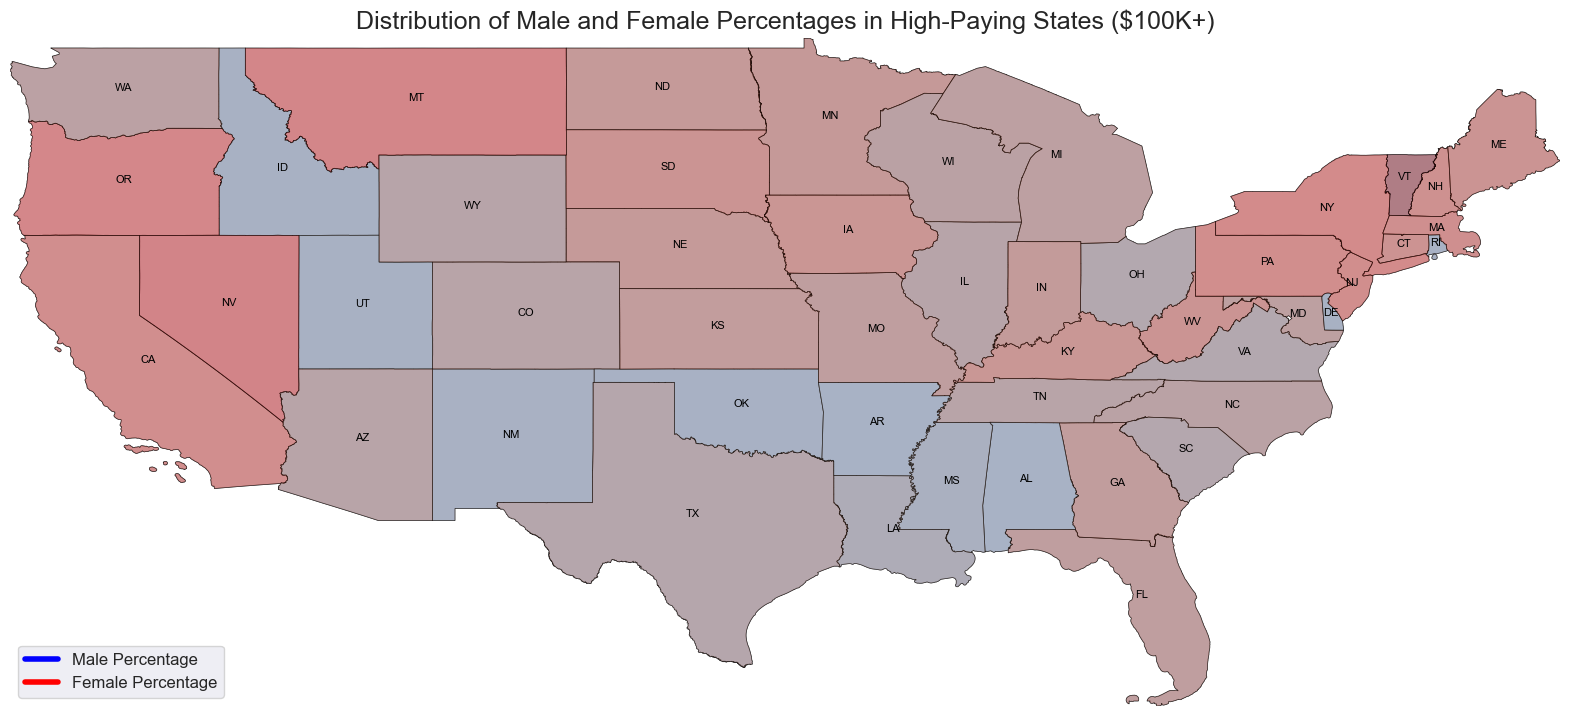

In [ ]:
# Call the function to plot the gender distribution
plot_gender_distribution(geo_gender_df)

---

### Question 5: How do regional patterns (Northeast, South, Midwest, West) compare in high-paying job opportunities and income levels?

#### Data Preparation

In [ ]:
# Question 5: Regional Analysis - Data Preparation
print("🗺️  Analyzing regional patterns across the United States...")

# Define US regions
us_regions = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT'],
    'South': ['AL', 'AR', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV'],
    'Midwest': ['IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH', 'SD', 'WI'],
    'West': ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NV', 'NM', 'OR', 'UT', 'WA', 'WY']
}

# Create region mapping
state_to_region = {}
for region, states in us_regions.items():
    for state in states:
        state_to_region[state] = region

# Add region column to data
high_pay_data['Region'] = high_pay_data['State Abbreviation'].map(state_to_region)

# Regional analysis
regional_stats = high_pay_data.groupby('Region').agg({
    'Annual Income': ['mean', 'median', 'std', 'count'],
    'State Abbreviation': 'nunique',
    'Gender': lambda x: (x == 'Female').sum() / len(x) * 100,  # Female percentage
    'Education Level': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'  # Dominant education
}).round(2)

# Flatten column names
regional_stats.columns = ['_'.join(col).strip() for col in regional_stats.columns]
regional_stats = regional_stats.rename(columns={
    'Annual Income_mean': 'Avg_Income',
    'Annual Income_median': 'Median_Income', 
    'Annual Income_std': 'Income_StdDev',
    'Annual Income_count': 'Total_Jobs',
    'State Abbreviation_nunique': 'Num_States',
    'Gender_<lambda>': 'Female_Percentage',
    'Education Level_<lambda>': 'Dominant_Education'
})

print("✅ Regional analysis data prepared")
print(f"📊 Regions analyzed: {list(regional_stats.index)}")
print(f"📈 Total jobs across regions: {regional_stats['Total_Jobs'].sum():,}")

# Display summary
print(f"\n🔍 Regional Overview:")
for region in regional_stats.index:
    stats = regional_stats.loc[region]
    print(f"   • {region}: ${stats['Avg_Income']:,.0f} avg, {stats['Total_Jobs']:,} jobs, {stats['Num_States']} states")

#### Visualization: Regional Analysis

In [ ]:
# Question 5 Visualization: Comprehensive Regional Analysis
print("🎨 Creating comprehensive regional pattern analysis...")

# Create 2x2 subplot for regional analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16), dpi=300)

# Professional color scheme for regions
region_colors = {
    'Northeast': '#FF6B6B',  # Red
    'South': '#4ECDC4',      # Teal  
    'Midwest': '#45B7D1',    # Blue
    'West': '#96CEB4'        # Green
}

# 1. Average Income by Region
regions = regional_stats.index
avg_incomes = regional_stats['Avg_Income']
colors1 = [region_colors[region] for region in regions]

bars1 = ax1.bar(regions, avg_incomes, color=colors1, alpha=0.8, edgecolor='black')
ax1.set_title('Average Income by Region\nHigh-Paying Jobs ($100K+)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Annual Income ($)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar, value in zip(bars1, avg_incomes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_incomes)*0.01,
            f'${value:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Job Distribution by Region (Pie Chart)
job_counts = regional_stats['Total_Jobs']
wedges, texts, autotexts = ax2.pie(job_counts.values, labels=job_counts.index, autopct='%1.1f%%',
                                  colors=[region_colors[region] for region in job_counts.index],
                                  startangle=90, textprops={'fontsize': 11})
ax2.set_title('Job Distribution by Region\nTotal High-Paying Positions', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Regional Income vs Job Volume Scatter
ax3.scatter(regional_stats['Total_Jobs'], regional_stats['Avg_Income'], 
           c=[region_colors[region] for region in regional_stats.index],
           s=300, alpha=0.7, edgecolors='black', linewidth=2)

# Add region labels
for i, region in enumerate(regional_stats.index):
    ax3.annotate(region, 
                (regional_stats.iloc[i]['Total_Jobs'], regional_stats.iloc[i]['Avg_Income']),
                xytext=(10, 10), textcoords='offset points', 
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=region_colors[region], alpha=0.7))

ax3.set_xlabel('Total High-Paying Jobs', fontsize=12)
ax3.set_ylabel('Average Income ($)', fontsize=12)
ax3.set_title('Regional Market Analysis\nIncome vs Job Volume', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Regional Characteristics Comparison
characteristics = ['Avg_Income', 'Median_Income', 'Female_Percentage']
x = np.arange(len(characteristics))
width = 0.2

for i, region in enumerate(regions):
    values = [
        regional_stats.loc[region, 'Avg_Income'] / 1000,  # Convert to thousands for readability
        regional_stats.loc[region, 'Median_Income'] / 1000,
        regional_stats.loc[region, 'Female_Percentage']
    ]
    
    bars = ax4.bar(x + i*width, values, width, label=region, 
                  color=region_colors[region], alpha=0.8, edgecolor='black')

ax4.set_xlabel('Characteristics', fontsize=12)
ax4.set_ylabel('Values', fontsize=12)
ax4.set_title('Regional Characteristics Comparison\n(Income in $1000s, Gender %)', fontsize=14, fontweight='bold')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(['Avg Income\n($1000s)', 'Median Income\n($1000s)', 'Female %'])
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.suptitle('Question 5: Regional Patterns in High-Paying Jobs Analysis', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the plot
os.makedirs("Images", exist_ok=True)
plt.savefig('Images/Regional_Patterns_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Question 5 regional analysis completed!")
print(f"📊 Key Insights:")
print(f"   • Highest Income Region: {regional_stats['Avg_Income'].idxmax()} (${regional_stats['Avg_Income'].max():,.0f})")
print(f"   • Largest Job Market: {regional_stats['Total_Jobs'].idxmax()} ({regional_stats['Total_Jobs'].max():,} jobs)")
print(f"   • Most Gender Balanced: {regional_stats['Female_Percentage'].idxmax()} ({regional_stats['Female_Percentage'].max():.1f}% female)")

# Create summary table
print(f"\n📋 Regional Summary Table:")
print(regional_stats[['Avg_Income', 'Total_Jobs', 'Num_States', 'Female_Percentage']].round(0))

---

### Question 6: What is the relationship between education level and income premiums across different states?

#### Data Preparation

In [ ]:
# Question 6: Education-Income Premium Analysis by State
print("🎓 Analyzing education level and income premium relationships...")

# Calculate income by education level nationally (baseline)
national_education_income = high_pay_data.groupby('Education Level')['Annual Income'].mean()
bachelor_baseline = national_education_income.get("Bachelor's degree", 0)

print(f"📊 National baseline (Bachelor's): ${bachelor_baseline:,.0f}")

# Calculate education premiums by state
state_education_analysis = []

for state in high_pay_data['State Abbreviation'].unique():
    state_data = high_pay_data[high_pay_data['State Abbreviation'] == state]
    
    # Get income by education for this state
    state_edu_income = state_data.groupby('Education Level')['Annual Income'].mean()
    
    # Calculate premiums relative to bachelor's degree
    bachelor_income = state_edu_income.get("Bachelor's degree", 0)
    
    if bachelor_income > 0:  # Only if state has bachelor's degree data
        for edu_level, income in state_edu_income.items():
            premium_pct = ((income - bachelor_income) / bachelor_income) * 100 if bachelor_income > 0 else 0
            premium_dollar = income - bachelor_income
            
            state_education_analysis.append({
                'State': state,
                'Education_Level': edu_level,
                'Income': income,
                'Premium_Percent': premium_pct,
                'Premium_Dollar': premium_dollar,
                'Sample_Size': len(state_data[state_data['Education Level'] == edu_level])
            })

# Convert to DataFrame
edu_premium_df = pd.DataFrame(state_education_analysis)

# Calculate state-level education diversity and premium metrics
state_edu_metrics = high_pay_data.groupby('State Abbreviation').agg({
    'Education Level': ['nunique', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'],
    'Annual Income': ['mean', 'std']
}).round(2)

# Flatten columns
state_edu_metrics.columns = ['_'.join(col).strip() for col in state_edu_metrics.columns]
state_edu_metrics = state_edu_metrics.rename(columns={
    'Education Level_nunique': 'Education_Diversity',
    'Education Level_<lambda>': 'Dominant_Education',
    'Annual Income_mean': 'State_Avg_Income',
    'Annual Income_std': 'Income_Variability'
})

# Calculate highest premium states for advanced degrees
advanced_premiums = edu_premium_df[
    edu_premium_df['Education_Level'].isin(['Master\'s degree', 'Professional degree', 'Doctoral degree'])
].groupby('State')['Premium_Percent'].mean().sort_values(ascending=False)

print("✅ Education-income premium analysis completed")
print(f"📈 States with highest education premiums: {advanced_premiums.head(3).round(1).to_dict()}")
print(f"🎯 Education levels analyzed: {edu_premium_df['Education_Level'].unique()}")

# Show sample of premium data
print(f"\n💡 Sample Education Premium Analysis:")
sample_states = ['CA', 'NY', 'TX', 'FL', 'ND']
for state in sample_states:
    if state in advanced_premiums.index:
        print(f"   • {state}: {advanced_premiums[state]:.1f}% premium for advanced degrees")

#### Visualization: Education-Income Premium Analysis

In [ ]:
# Question 6 Visualization: Education-Income Premium Analysis
print("🎨 Creating education-income premium analysis...")

# Create comprehensive education premium visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16), dpi=300)

# Education level colors
edu_colors = {
    "Bachelor's degree": '#3498DB',      # Blue
    "Master's degree": '#E74C3C',        # Red  
    "Professional degree": '#F39C12',    # Orange
    "Doctoral degree": '#9B59B6'         # Purple
}

# 1. Top 15 States by Advanced Degree Premium
top_premium_states = advanced_premiums.head(15)
bars1 = ax1.barh(range(len(top_premium_states)), top_premium_states.values, 
                color='#2ECC71', alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(top_premium_states)))
ax1.set_yticklabels(top_premium_states.index)
ax1.set_xlabel('Premium Percentage (%)', fontsize=12)
ax1.set_title('Top 15 States by Education Premium\n(Advanced Degrees vs Bachelor\'s)', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars1, top_premium_states.values)):
    ax1.text(bar.get_width() + max(top_premium_states.values)*0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}%', va='center', fontsize=10)

# 2. National Education Level Income Distribution
national_edu_income = high_pay_data.groupby('Education Level')['Annual Income'].mean().sort_values(ascending=True)
colors2 = [edu_colors.get(edu, '#BDC3C7') for edu in national_edu_income.index]

bars2 = ax2.barh(range(len(national_edu_income)), national_edu_income.values, 
                color=colors2, alpha=0.8, edgecolor='black')
ax2.set_yticks(range(len(national_edu_income)))
ax2.set_yticklabels([edu.replace(' degree', '') for edu in national_edu_income.index])
ax2.set_xlabel('Average Annual Income ($)', fontsize=12)
ax2.set_title('National Income by Education Level\nHigh-Paying Jobs ($100K+)', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars2, national_edu_income.values)):
    ax2.text(bar.get_width() + max(national_edu_income.values)*0.01, bar.get_y() + bar.get_height()/2,
            f'${value:,.0f}', va='center', fontsize=10)

# 3. Education Diversity by State (Top 15)
top_diverse_states = state_edu_metrics.nlargest(15, 'Education_Diversity')
bars3 = ax3.bar(range(len(top_diverse_states)), top_diverse_states['Education_Diversity'],
               color='#E67E22', alpha=0.8, edgecolor='black')
ax3.set_xticks(range(len(top_diverse_states)))
ax3.set_xticklabels(top_diverse_states.index, rotation=45, ha='right')
ax3.set_ylabel('Number of Education Levels', fontsize=12)
ax3.set_title('Top 15 States by Education Diversity\nVariety of Education Levels', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars3, top_diverse_states['Education_Diversity'])):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(int(value)), ha='center', va='bottom', fontsize=10)

# 4. Income Variability vs Education Diversity Scatter
scatter = ax4.scatter(state_edu_metrics['Education_Diversity'], 
                     state_edu_metrics['Income_Variability'],
                     c=state_edu_metrics['State_Avg_Income'], 
                     s=100, alpha=0.7, cmap='viridis', edgecolors='black')

ax4.set_xlabel('Education Diversity (# of Levels)', fontsize=12)
ax4.set_ylabel('Income Variability (Std Dev)', fontsize=12)
ax4.set_title('Education Diversity vs Income Variability\nby State', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Average State Income ($)', fontsize=10)

# Add trend line
z = np.polyfit(state_edu_metrics['Education_Diversity'], state_edu_metrics['Income_Variability'], 1)
p = np.poly1d(z)
ax4.plot(state_edu_metrics['Education_Diversity'], p(state_edu_metrics['Education_Diversity']), 
         "r--", alpha=0.8, linewidth=2)

plt.suptitle('Question 6: Education-Income Premium Analysis by State', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the plot  
os.makedirs("Images", exist_ok=True)
plt.savefig('Images/Education_Income_Premium_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Question 6 education-income premium analysis completed!")
print(f"📊 Key Insights:")
print(f"   • Highest Education Premium: {advanced_premiums.idxmax()} ({advanced_premiums.max():.1f}%)")
print(f"   • Highest Income Education: {national_edu_income.idxmax()} (${national_edu_income.max():,.0f})")
print(f"   • Most Educationally Diverse: {state_edu_metrics['Education_Diversity'].idxmax()} ({state_edu_metrics['Education_Diversity'].max():.0f} levels)")

# Create premium summary
print(f"\n💰 Education Premium Summary (vs Bachelor's degree):")
for edu_level in ['Master\'s degree', 'Professional degree', 'Doctoral degree']:
    if edu_level in national_edu_income.index:
        bachelor_income = national_edu_income.get("Bachelor's degree", 0)
        premium = ((national_edu_income[edu_level] - bachelor_income) / bachelor_income) * 100
        print(f"   • {edu_level}: +{premium:.1f}% (${national_edu_income[edu_level] - bachelor_income:,.0f})")

---

### Question 7: How do industries/occupations distribute geographically in terms of high-paying opportunities?

#### Data Preparation & Visualization

In [ ]:
# Question 7: Geographic Distribution of Industries/Occupations
print("🏭 Analyzing geographic distribution of high-paying industries...")

# Get top occupations nationally
top_occupations = high_pay_data['Occupation_Title'].value_counts().head(10)
print(f"📊 Top 10 Occupations: {list(top_occupations.index)}")

# Analyze geographic concentration for each top occupation
occupation_geography = {}

for occupation in top_occupations.index:
    occ_data = high_pay_data[high_pay_data['Occupation_Title'] == occupation]
    
    # Get state distribution for this occupation
    state_dist = occ_data['State Abbreviation'].value_counts()
    
    # Calculate concentration metrics
    total_jobs = len(occ_data)
    top_state = state_dist.index[0] if len(state_dist) > 0 else 'N/A'
    top_state_pct = (state_dist.iloc[0] / total_jobs * 100) if len(state_dist) > 0 else 0
    avg_income = occ_data['Annual Income'].mean()
    
    occupation_geography[occupation] = {
        'Total_Jobs': total_jobs,
        'Top_State': top_state,
        'Top_State_Percentage': top_state_pct,
        'Avg_Income': avg_income,
        'State_Distribution': state_dist.head(5).to_dict(),
        'Geographic_Spread': len(state_dist)  # Number of states with this occupation
    }

# Create comprehensive industry geography visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16), dpi=300)

# 1. Occupation Concentration by Top State
occupations = list(occupation_geography.keys())[:8]  # Top 8 for readability
top_state_pcts = [occupation_geography[occ]['Top_State_Percentage'] for occ in occupations]

bars1 = ax1.barh(range(len(occupations)), top_state_pcts, 
                color=plt.cm.viridis(np.linspace(0, 1, len(occupations))), 
                alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(occupations)))
ax1.set_yticklabels([occ.replace(' ', '\n') if len(occ) > 20 else occ for occ in occupations], fontsize=10)
ax1.set_xlabel('Concentration in Top State (%)', fontsize=12)
ax1.set_title('Geographic Concentration by Occupation\n% Jobs in Dominant State', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars1, top_state_pcts)):
    ax1.text(bar.get_width() + max(top_state_pcts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}%', va='center', fontsize=10)

# 2. Geographic Spread vs Average Income
spread_values = [occupation_geography[occ]['Geographic_Spread'] for occ in occupations]
income_values = [occupation_geography[occ]['Avg_Income'] for occ in occupations]

scatter = ax2.scatter(spread_values, income_values, 
                     c=top_state_pcts, s=150, alpha=0.7, 
                     cmap='plasma', edgecolors='black')
ax2.set_xlabel('Geographic Spread (# States)', fontsize=12)
ax2.set_ylabel('Average Income ($)', fontsize=12)
ax2.set_title('Geographic Spread vs Income\nby Occupation', fontsize=14, fontweight='bold')

# Add occupation labels
for i, occ in enumerate(occupations):
    ax2.annotate(occ.split()[-1], (spread_values[i], income_values[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

cbar2 = plt.colorbar(scatter, ax=ax2)
cbar2.set_label('Top State Concentration (%)', fontsize=10)

# 3. Regional Occupation Dominance
region_occupation = high_pay_data.groupby(['Region', 'Occupation_Title']).size().unstack(fill_value=0)
# Get top 5 occupations for each region
regional_leaders = {}
for region in region_occupation.index:
    top_occs = region_occupation.loc[region].nlargest(3)
    regional_leaders[region] = top_occs.to_dict()

# Create stacked bar for regional occupation mix
top_5_occs = top_occupations.head(5).index
region_data = []
for region in high_pay_data['Region'].unique():
    if pd.notna(region):
        region_totals = high_pay_data[high_pay_data['Region'] == region]['Occupation_Title'].value_counts()
        for occ in top_5_occs:
            count = region_totals.get(occ, 0)
            region_data.append({'Region': region, 'Occupation': occ, 'Count': count})

region_occ_df = pd.DataFrame(region_data)
pivot_data = region_occ_df.pivot(index='Region', columns='Occupation', values='Count').fillna(0)

# Plot stacked bar
bottom = np.zeros(len(pivot_data.index))
colors3 = plt.cm.Set3(np.linspace(0, 1, len(pivot_data.columns)))

for i, occ in enumerate(pivot_data.columns):
    ax3.bar(pivot_data.index, pivot_data[occ], bottom=bottom, 
           label=occ.split()[-2:] if len(occ.split()) > 2 else occ,  # Shortened labels
           color=colors3[i], alpha=0.8)
    bottom += pivot_data[occ]

ax3.set_ylabel('Number of Jobs', fontsize=12)
ax3.set_title('Top Occupations by Region\nHigh-Paying Jobs Distribution', fontsize=14, fontweight='bold')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax3.tick_params(axis='x', rotation=45)

# 4. State Specialization Index (top states for specific occupations)
# Calculate location quotient for top occupation-state combinations
specialization_data = []
for state in high_pay_data['State Abbreviation'].unique():
    state_total = len(high_pay_data[high_pay_data['State Abbreviation'] == state])
    if state_total >= 20:  # Only states with significant sample size
        for occ in top_occupations.head(6).index:
            state_occ_count = len(high_pay_data[
                (high_pay_data['State Abbreviation'] == state) & 
                (high_pay_data['Occupation_Title'] == occ)
            ])
            
            if state_occ_count > 0:
                # Simple specialization score: (state_occ% / national_occ%) * 100
                national_occ_pct = len(high_pay_data[high_pay_data['Occupation_Title'] == occ]) / len(high_pay_data)
                state_occ_pct = state_occ_count / state_total
                specialization_score = (state_occ_pct / national_occ_pct) if national_occ_pct > 0 else 0
                
                specialization_data.append({
                    'State': state,
                    'Occupation': occ,
                    'Specialization_Score': specialization_score,
                    'Job_Count': state_occ_count
                })

spec_df = pd.DataFrame(specialization_data)
top_specializations = spec_df.nlargest(15, 'Specialization_Score')

bars4 = ax4.barh(range(len(top_specializations)), top_specializations['Specialization_Score'],
                color='#FF6B6B', alpha=0.8, edgecolor='black')
ax4.set_yticks(range(len(top_specializations)))
labels4 = [f"{row['State']}: {row['Occupation'].split()[-1]}" for _, row in top_specializations.iterrows()]
ax4.set_yticklabels(labels4, fontsize=9)
ax4.set_xlabel('Specialization Score (>1 = Above National Average)', fontsize=12)
ax4.set_title('Top 15 State-Occupation Specializations\nRelative Concentration Index', fontsize=14, fontweight='bold')
ax4.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='National Average')
ax4.legend()

plt.suptitle('Question 7: Geographic Distribution of High-Paying Industries/Occupations', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the plot
os.makedirs("Images", exist_ok=True)
plt.savefig('Images/Industry_Geographic_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Question 7 industry geographic analysis completed!")
print(f"📊 Key Insights:")
most_concentrated = max(occupation_geography.items(), key=lambda x: x[1]['Top_State_Percentage'])
most_spread = max(occupation_geography.items(), key=lambda x: x[1]['Geographic_Spread'])
print(f"   • Most Geographically Concentrated: {most_concentrated[0]} ({most_concentrated[1]['Top_State_Percentage']:.1f}% in {most_concentrated[1]['Top_State']})")
print(f"   • Most Geographically Spread: {most_spread[0]} ({most_spread[1]['Geographic_Spread']} states)")

if len(top_specializations) > 0:
    top_spec = top_specializations.iloc[0]
    print(f"   • Highest Specialization: {top_spec['State']} in {top_spec['Occupation']} ({top_spec['Specialization_Score']:.1f}x national average)")

---

### Question 8: How does job market size correlate with income premiums across states (market size vs premium analysis)?

#### Data Preparation & Visualization

In [ ]:
# Question 8: Market Size vs Income Premium Analysis
print("📈 Analyzing relationship between market size and income premiums...")

# Calculate market metrics for each state
market_analysis = high_pay_data.groupby('State Abbreviation').agg({
    'Annual Income': ['mean', 'median', 'std', 'count'],
    'Employment': 'sum'
}).round(2)

# Flatten column names
market_analysis.columns = ['_'.join(col).strip() for col in market_analysis.columns]
market_analysis = market_analysis.rename(columns={
    'Annual Income_mean': 'Avg_Income',
    'Annual Income_median': 'Median_Income',
    'Annual Income_std': 'Income_StdDev', 
    'Annual Income_count': 'Job_Count',
    'Employment_sum': 'Total_Employment'
})

# Calculate market premium (relative to national average)
national_avg_income = high_pay_data['Annual Income'].mean()
market_analysis['Income_Premium'] = ((market_analysis['Avg_Income'] - national_avg_income) / national_avg_income) * 100

# Define market size categories
job_count_terciles = np.percentile(market_analysis['Job_Count'], [33, 67])
market_analysis['Market_Size'] = pd.cut(
    market_analysis['Job_Count'], 
    bins=[0, job_count_terciles[0], job_count_terciles[1], float('inf')],
    labels=['Small', 'Medium', 'Large']
)

# Calculate correlation between market size and income
correlation_job_income = market_analysis['Job_Count'].corr(market_analysis['Avg_Income'])
correlation_employment_income = market_analysis['Total_Employment'].corr(market_analysis['Avg_Income'])

print(f"✅ Market analysis completed")
print(f"📊 Correlation (Job Count vs Income): {correlation_job_income:.3f}")
print(f"📊 Correlation (Total Employment vs Income): {correlation_employment_income:.3f}")

# Create comprehensive market analysis visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16), dpi=300)

# 1. Market Size vs Average Income Scatter Plot
market_colors = {'Small': '#E74C3C', 'Medium': '#F39C12', 'Large': '#27AE60'}
for market_size in ['Small', 'Medium', 'Large']:
    mask = market_analysis['Market_Size'] == market_size
    ax1.scatter(market_analysis[mask]['Job_Count'], 
               market_analysis[mask]['Avg_Income'],
               c=market_colors[market_size], label=f'{market_size} Market', 
               s=100, alpha=0.7, edgecolors='black')

# Add trend line
z = np.polyfit(market_analysis['Job_Count'], market_analysis['Avg_Income'], 1)
p = np.poly1d(z)
ax1.plot(market_analysis['Job_Count'], p(market_analysis['Job_Count']), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend (r={correlation_job_income:.3f})')

ax1.set_xlabel('Job Count (High-Paying Positions)', fontsize=12)
ax1.set_ylabel('Average Income ($)', fontsize=12)
ax1.set_title('Market Size vs Average Income\nby State', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate extreme points
top_income_states = market_analysis.nlargest(3, 'Avg_Income')
large_markets = market_analysis.nlargest(3, 'Job_Count')

for idx, row in top_income_states.iterrows():
    ax1.annotate(idx, (row['Job_Count'], row['Avg_Income']), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# 2. Income Premium vs Market Size
market_size_stats = market_analysis.groupby('Market_Size').agg({
    'Income_Premium': ['mean', 'std', 'count'],
    'Avg_Income': 'mean'
}).round(2)

market_size_stats.columns = ['_'.join(col).strip() for col in market_size_stats.columns]
market_sizes = ['Small', 'Medium', 'Large']
premiums = [market_size_stats.loc[size, 'Income_Premium_mean'] for size in market_sizes]
premium_stds = [market_size_stats.loc[size, 'Income_Premium_std'] for size in market_sizes]

bars2 = ax2.bar(market_sizes, premiums, 
               color=[market_colors[size] for size in market_sizes],
               alpha=0.8, edgecolor='black', 
               yerr=premium_stds, capsize=5)
ax2.set_ylabel('Average Income Premium (%)', fontsize=12)
ax2.set_title('Income Premium by Market Size\n(Relative to National Average)', fontsize=14, fontweight='bold')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='National Average')
ax2.legend()

# Add value labels
for bar, value in zip(bars2, premiums):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(premiums)*0.01,
            f'{value:+.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Market Concentration Analysis (Top 15 states)
top_15_markets = market_analysis.nlargest(15, 'Job_Count')
bars3 = ax3.bar(range(len(top_15_markets)), top_15_markets['Job_Count'],
               color=plt.cm.viridis(np.linspace(0, 1, len(top_15_markets))),
               alpha=0.8, edgecolor='black')
ax3.set_xticks(range(len(top_15_markets)))
ax3.set_xticklabels(top_15_markets.index, rotation=45, ha='right')
ax3.set_ylabel('Number of High-Paying Jobs', fontsize=12)
ax3.set_title('Top 15 States by Market Size\nHigh-Paying Job Count', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars3, top_15_markets['Job_Count'])):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(top_15_markets['Job_Count'])*0.01,
            f'{value:,}', ha='center', va='bottom', fontsize=9, rotation=90)

# 4. Market Efficiency (Income per Job) Analysis
market_analysis['Income_per_Job_Ratio'] = market_analysis['Avg_Income'] / market_analysis['Job_Count'] * 1000  # Scale for readability
top_efficient = market_analysis.nlargest(15, 'Income_per_Job_Ratio')

bars4 = ax4.barh(range(len(top_efficient)), top_efficient['Income_per_Job_Ratio'],
                color='#9B59B6', alpha=0.8, edgecolor='black')
ax4.set_yticks(range(len(top_efficient)))
ax4.set_yticklabels(top_efficient.index)
ax4.set_xlabel('Income Efficiency Ratio\n(Income × 1000 / Job Count)', fontsize=12)
ax4.set_title('Top 15 Most Efficient Markets\nHigh Income-to-Volume Ratio', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars4, top_efficient['Income_per_Job_Ratio'])):
    ax4.text(bar.get_width() + max(top_efficient['Income_per_Job_Ratio'])*0.01, 
            bar.get_y() + bar.get_height()/2,
            f'{value:.1f}', va='center', fontsize=10)

plt.suptitle('Question 8: Market Size vs Income Premium Analysis by State', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the plot
os.makedirs("Images", exist_ok=True)
plt.savefig('Images/Market_Size_Income_Premium_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Question 8 market analysis completed!")

# Summary insights
print(f"\n📊 Market Analysis Key Insights:")
print(f"   • Correlation (Market Size ↔ Income): {correlation_job_income:.3f}")
print(f"   • Large Markets Average Premium: {market_size_stats.loc['Large', 'Income_Premium_mean']:+.1f}%")
print(f"   • Small Markets Average Premium: {market_size_stats.loc['Small', 'Income_Premium_mean']:+.1f}%")
print(f"   • Most Efficient Market: {top_efficient.index[0]} (ratio: {top_efficient.iloc[0]['Income_per_Job_Ratio']:.1f})")
print(f"   • Largest Market: {large_markets.index[0]} ({large_markets.iloc[0]['Job_Count']:,} jobs)")

# Market classification summary
print(f"\n🏢 Market Classification Summary:")
for size in ['Small', 'Medium', 'Large']:
    count = market_size_stats.loc[size, 'Income_Premium_count']
    avg_income = market_size_stats.loc[size, 'Income_Premium_mean']
    print(f"   • {size} Markets: {count:.0f} states, {avg_income:+.1f}% average premium")

print(f"\n🎯 Conclusion: Market size {'positively' if correlation_job_income > 0 else 'negatively'} correlates with income (r={correlation_job_income:.3f})")